<a href="https://colab.research.google.com/github/marescost4/Seminario01/blob/main/Semin%C3%A1rio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Bioestatística - Seminário



*   Mariane Santana 16890981
*   David Souza 16965966
*   Fillipy Leal 17097358



##Análise descritiva da massa corporal e características morfológicas de artrópodes tropicais e temperados

#Objetivo
Descrever a distribuição da massa corporal, comprimento e largura dos artrópodes, além da análise entre regiões geográficas e grupos taxonômicos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("DadosSeminário01.xlsx")

# Rename columns to Portuguese
df = df.rename(columns={
    "Live body mass (mg)": "Massa corporal (mg)",
    "Body length (mm)": "Comprimento corporal (mm)",
    "Body width (mm)": "Largura corporal (mm)"
})

df.head()

,Order,Suborder,Family,Massa corporal (mg),Comprimento corporal (mm),Largura corporal (mm),Geographic Region,Groups for Table S1,Analysis
0,coleoptera,NaN,carabidae,152.30,14.60,6.08,temperate,Coleoptera (other),Main Analysis and Supporting Information
1,diptera,brachycera,lauxaniidae,4.15,4.90,1.50,tropical,Diptera (Brachycera),Main Analysis and Supporting Information
2,coleoptera,polyphaga,staphylinidae,0.25,2.56,4.97,tropical,Coleoptera (Staphylinidae),Main Analysis and Supporting Information
3,araneae,labidognatha,araneidae,8.71,3.46,3.66,tropical,Araneae (webbuilding),Main Analysis and Supporting Information
4,araneae,labidognatha,araneidae,16.17,4.14,4.29,tropical,Araneae (webbuilding),Main Analysis and Supporting Information


In [2]:
print("Número de indivíduos:", df.shape[0])
print("Número de variáveis:", df.shape[1])

print("\nVariáveis:")
print(df.columns.tolist())

Número de indivíduos: 6608
Número de variáveis: 9

Variáveis:
['Order', 'Suborder', 'Family', 'Massa corporal (mg)', 'Comprimento corporal (mm)', 'Largura corporal (mm)', 'Geographic Region', 'Groups for Table S1', 'Analysis']


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6608 entries, 0 to 6607
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Order                      6608 non-null   object 
 1   Suborder                   5233 non-null   object 
 2   Family                     6608 non-null   object 
 3   Massa corporal (mg)        6608 non-null   float64
 4   Comprimento corporal (mm)  6608 non-null   float64
 5   Largura corporal (mm)      6295 non-null   float64
 6   Geographic Region          6608 non-null   object 
 7   Groups for Table S1        4927 non-null   object 
 8   Analysis                   6608 non-null   object 
dtypes: float64(3), object(6)
memory usage: 464.8+ KB


Para a análise vão ser utilizadas apenas
- Massa corporal (live body mass (mg)) - Quantitativa
- Comprimento corporal (Body Length (mm)) - Quantitativa
- Largura corporal (Body width (mm)) - Quantitativa
- Região geográfica (geographic region) - Categórica
- ordem taxonômica (Order) - Categórica

##Distribuição dos indivíduos - Região temperada x tropical

In [4]:
df["Geographic Region"].value_counts()

,count
Geographic Region,
tropical,3547
temperate,3061


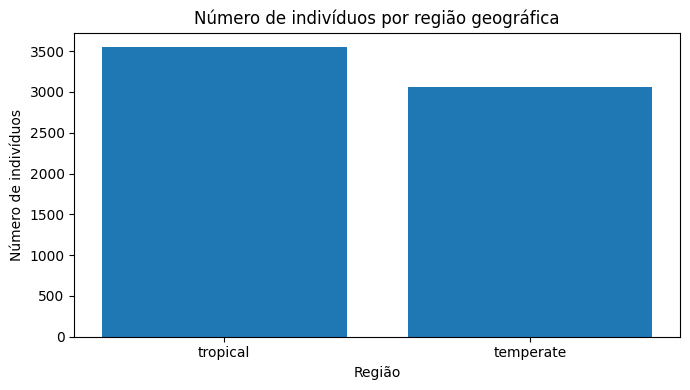

In [5]:
contagem = df["Geographic Region"].value_counts()

plt.figure(figsize=(7,4))

plt.bar(contagem.index, contagem.values)

plt.title("Número de indivíduos por região geográfica")
plt.xlabel("Região")
plt.ylabel("Número de indivíduos")

plt.tight_layout()
plt.show()

Os dados apresenta indivíduos de regiões tropicais e temperadas. Essa distribuição permite realizar uma comparação descritiva das características corporais entre essas duas regiões.

##Estatística descritiva das variáveis

calcular:
média;
mediana;
variância;
desvio-padrão;
mínimo;
máximo;
quartis;
amplitude;
IQR;
coeficiente de variação.



In [6]:
variaveis = ["Massa corporal (mg)","Comprimento corporal (mm)","Largura corporal (mm)"]

In [7]:
desc_df = df[variaveis].describe()


amplitude = df[variaveis].max() - df[variaveis].min()
iqr = desc_df.loc['75%'] - desc_df.loc['25%']

cv = (desc_df.loc['std'] / desc_df.loc['mean']) * 100

additional_stats = pd.DataFrame({'Amplitude': amplitude,'IQR': iqr,'CV': cv}).T

combined_df = pd.concat([desc_df, additional_stats])

# Rename the indices
combined_df = combined_df.rename(index={'count': 'Contagem','mean': 'Média','std': 'Desvio Padrão','min': 'Mínimo','max': 'Máximo','CV': 'Coeficiente de Variação'})

display(combined_df.round(2))

,Massa corporal (mg),Comprimento corporal (mm),Largura corporal (mm)
Contagem,6608.00,6608.00,6295.00
Média,28.14,6.84,1.90
Desvio Padrão,125.48,5.94,1.41
Mínimo,0.01,0.62,0.32
25%,1.87,3.25,1.03
50%,5.52,5.03,1.52
75%,18.04,8.30,2.24
Máximo,5108.57,68.12,20.02
Amplitude,5108.56,67.50,19.70
IQR,16.17,5.05,1.21


##Massa corporal

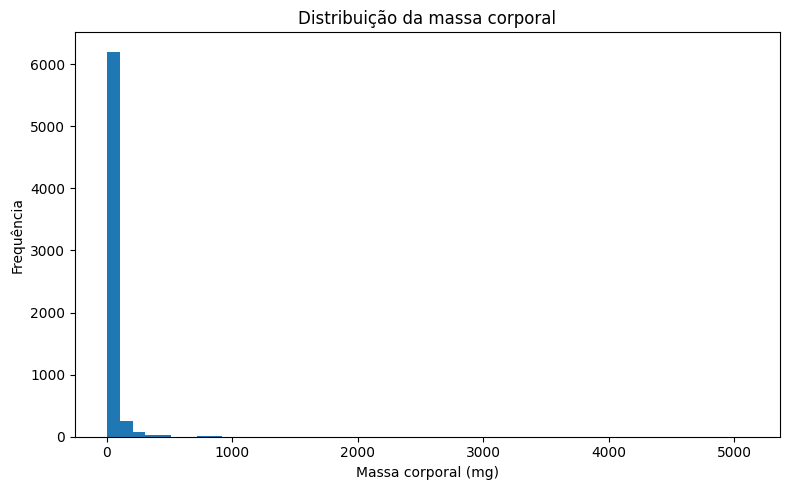

In [8]:
massa = df["Massa corporal (mg)"].dropna()

plt.figure(figsize=(8,5))

plt.hist(massa, bins=50)

plt.title("Distribuição da massa corporal")
plt.xlabel("Massa corporal (mg)")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

forte assimetria à direita

muitos indivíduos com massa relativamente baixa e poucos indivíduos com massas muito elevadas.

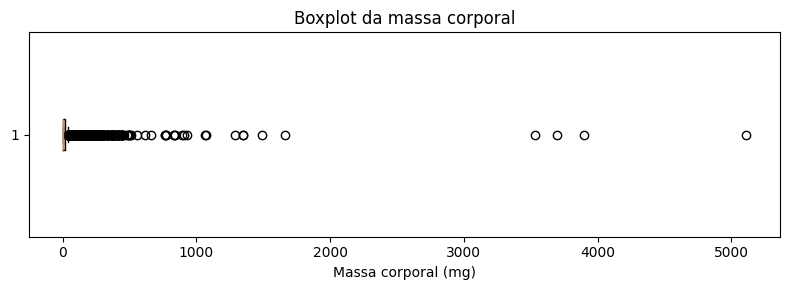

In [9]:
#boxplot
plt.figure(figsize=(8,3))

plt.boxplot(massa, vert=False)

plt.title("Boxplot da massa corporal")
plt.xlabel("Massa corporal (mg)")

plt.tight_layout()
plt.show()

Massa corporal:
média ≈ 28,14 mg
mediana ≈ 5,52 mg
desvio-padrão ≈ 125,48 mg


A massa corporal apresentou uma média de aproximadamente 28,14 mg, enquanto a mediana foi de apenas 5,52 mg. Essa grande diferença entre média e mediana indica uma distribuição fortemente assimétrica à direita. Isso ocorre porque alguns indivíduos apresentam massas muito maiores que a maioria da amostra.

In [ ]:
#observações atípicas
massa = df["Massa corporal (mg)"].dropna()

Q1 = massa.quantile(0.25)
Q3 = massa.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

atipicos = massa[
    (massa < limite_inferior) |
    (massa > limite_superior)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)
print("Número de possíveis observações atípicas:", len(atipicos))
print("Maior valor:", massa.max())

Q1: 1.8675000000000002
Q3: 18.04
IQR: 16.1725
Limite inferior: -22.39125
Limite superior: 42.29875
Número de possíveis observações atípicas: 869
Maior valor: 5108.57


##Região geográfica

In [10]:
grouped_stats = df.groupby("Geographic Region")[
    ["Massa corporal (mg)",
     "Comprimento corporal (mm)",
     "Largura corporal (mm)"]
].agg(["count", "mean", "median", "std", "min", "max"]).round(2)

# Renomeia as colunas para Português, se necessário para a exibição
grouped_stats.columns = grouped_stats.columns.set_levels(
    grouped_stats.columns.levels[1].map({
        'count': 'Contagem',
        'mean': 'Média',
        'median': 'Mediana',
        'std': 'Desvio Padrão',
        'min': 'Mínimo',
        'max': 'Máximo'
    }), level=1
)

# Renomeia os valores do índice para Português
grouped_stats = grouped_stats.rename(index={'temperate': 'Temperada', 'tropical': 'Tropical'})
grouped_stats.index.name = "Região Geográfica"

display(grouped_stats)

Massa corporal (mg)                                      \
                             Contagem  Média Mediana Desvio Padrão Mínimo   
Região Geográfica                                                           
Temperada                        3061  26.61    7.31         54.38   0.06   
Tropical                         3547  29.47    4.04        163.65   0.01   

                           Comprimento corporal (mm)                \
                    Máximo                  Contagem Média Mediana   
Região Geográfica                                                    
Temperada          1067.93                      3061  7.07    5.51   
Tropical           5108.57                      3547  6.65    4.61   

                                              Largura corporal (mm)        \
                  Desvio Padrão Mínimo Máximo              Contagem Média   
Região Geográfica                                                           
Temperada                  4.88   0.93  35.10                  2748  2.03   
Tropical                   6.72   0.62  68.12                  3547  1.81   

                                                       
                  Mediana Desvio Padrão Mínimo Máximo  
Região Geográfica                                      
Temperada            1.62          1.37   0.38  14.18  
Tropical             1.43          1.44   0.32  20.02

In [11]:
# Rename columns to Portuguese (already done in a previous cell, but keeping for consistency if this cell is run in isolation)
df = df.rename(columns={
    "Live body mass (mg)": "Massa corporal (mg)",
    "Body length (mm)": "Comprimento corporal (mm)",
    "Body width (mm)": "Largura corporal (mm)"
})

# Massa por região geográfica
summary_df = df.groupby("Geographic Region")["Massa corporal (mg)"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)

# Rename columns of the summary table to Portuguese
summary_df = summary_df.rename(columns={
    "count": "Contagem",
    "mean": "Média",
    "median": "Mediana",
    "std": "Desvio Padrão",
    "min": "Mínimo",
    "max": "Máximo"
})

# Rename the index name to Portuguese
summary_df.index.name = "Região Geográfica"

# Rename specific index values to Portuguese
summary_df = summary_df.rename(index={
    "temperate": "Temperada",
    "tropical": "Tropical"
})

display(summary_df)

,Contagem,Média,Mediana,Desvio Padrão,Mínimo,Máximo
Região Geográfica,,,,,,
Temperada,3061,26.61,7.31,54.38,0.06,1067.93
Tropical,3547,29.47,4.04,163.65,0.01,5108.57


##Largura corporal

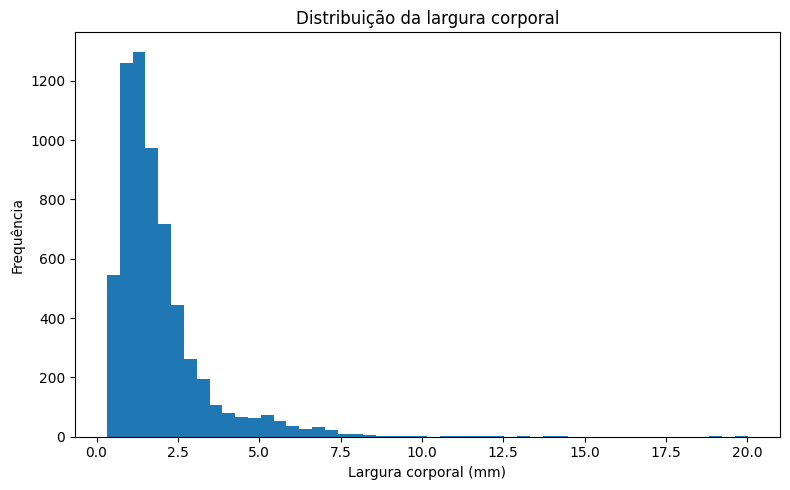

In [12]:
largura = df["Largura corporal (mm)"].dropna()

#histograma
plt.figure(figsize=(8,5))

plt.hist(largura, bins=50)

plt.title("Distribuição da largura corporal")
plt.xlabel("Largura corporal (mm)")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

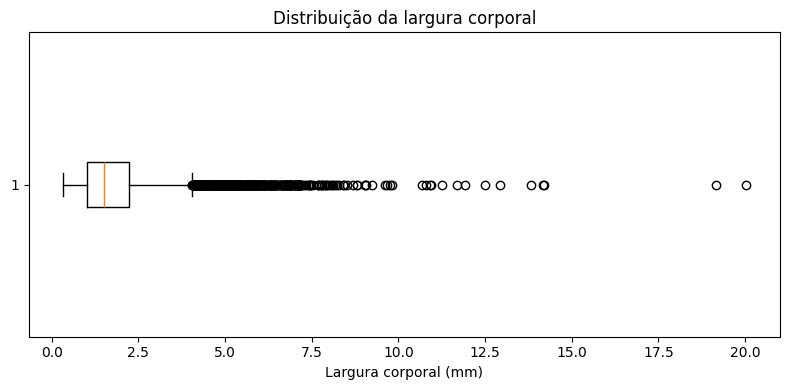

In [13]:
#boxplot
largura = df["Largura corporal (mm)"].dropna()

plt.figure(figsize=(8,4))

plt.boxplot(largura, vert=False)

plt.title("Distribuição da largura corporal")
plt.xlabel("Largura corporal (mm)")

plt.tight_layout()
plt.show()

In [14]:
largura = df["Largura corporal (mm)"].dropna()

Q1 = largura.quantile(0.25)
Q3 = largura.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

atipicos_largura = largura[
    (largura < limite_inferior) |
    (largura > limite_superior)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)
print("Número de possíveis atípicos:", len(atipicos_largura))
print("Maior largura:", largura.max())

Q1: 1.03
Q3: 2.24
IQR: 1.2100000000000002
Limite inferior: -0.7850000000000004
Limite superior: 4.055000000000001
Número de possíveis atípicos: 458
Maior largura: 20.02


##Relação Massa x Largura

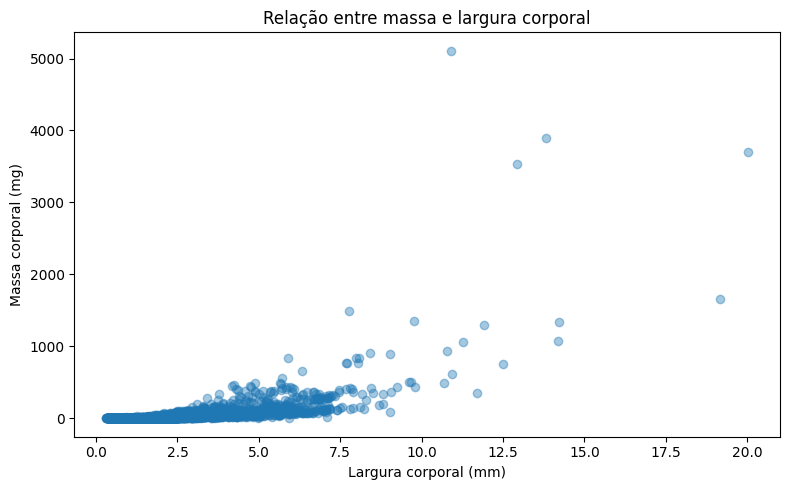

In [15]:
massa = df["Massa corporal (mg)"]
largura = df["Largura corporal (mm)"]

dados = pd.DataFrame({
    "Massa": massa,
    "Largura": largura
}).dropna()

plt.figure(figsize=(8,5))

plt.scatter(
    dados["Largura"],
    dados["Massa"],
    alpha=0.4
)

plt.xlabel("Largura corporal (mm)")
plt.ylabel("Massa corporal (mg)")
plt.title("Relação entre massa e largura corporal")

plt.tight_layout()
plt.show()

##Massa x Região

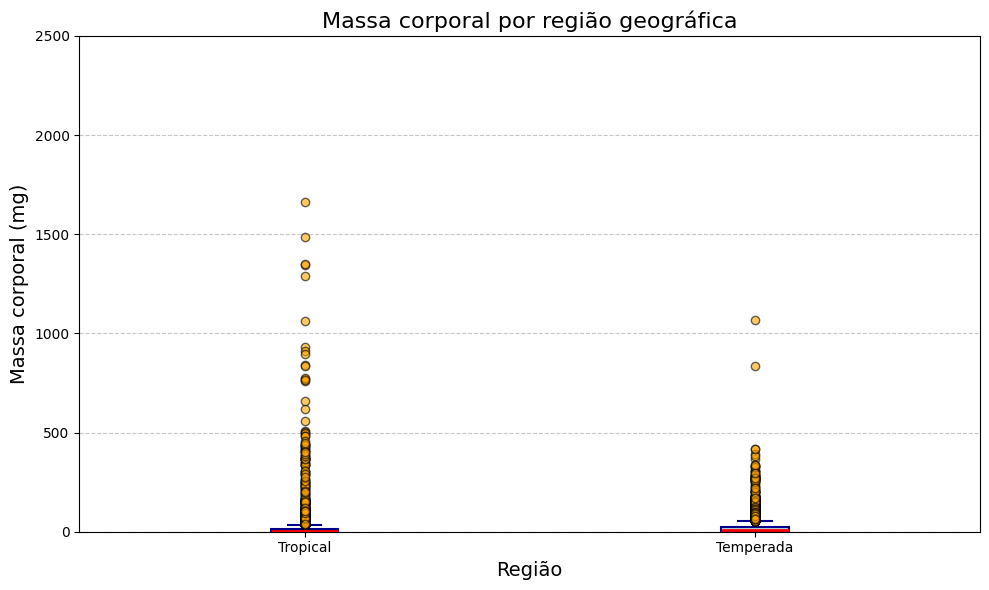

In [16]:
#Boxplot por região

tropical = df[
    df["Geographic Region"] == "tropical"
]["Massa corporal (mg)"].dropna()

temperate = df[df["Geographic Region"] == "temperate"]["Massa corporal (mg)"].dropna() # Corrected column name

plt.figure(figsize=(10,6))

plt.boxplot([tropical, temperate],
            tick_labels=["Tropical", "Temperada"],
            patch_artist=True, # Enable filling the box with color
            boxprops=dict(facecolor='lightblue', edgecolor='darkblue', linewidth=1.5), # Box color and border
            medianprops=dict(color='red', linewidth=2), # Median line color and width
            whiskerprops=dict(color='darkblue', linewidth=1.5), # Whisker color and width
            capprops=dict(color='darkblue', linewidth=1.5), # Cap color and width
            flierprops=dict(marker='o', markerfacecolor='orange', markersize=6, alpha=0.6) # Outlier customization
           )

plt.title("Massa corporal por região geográfica", fontsize=16)
plt.xlabel("Região", fontsize=14)
plt.ylabel("Massa corporal (mg)", fontsize=14)

plt.ylim(0, 2500)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability

plt.tight_layout()
plt.show()

In [17]:
mass_quantiles_by_region = df.groupby("Geographic Region")["Massa corporal (mg)"].agg(
    mean='mean',
    Q1=lambda x: x.quantile(0.25),
    Q2='median',
    Q3=lambda x: x.quantile(0.75)
).round(2)

# Renomear os índices para Português
mass_quantiles_by_region = mass_quantiles_by_region.rename(index={'temperate': 'Temperada', 'tropical': 'Tropical'})

display(mass_quantiles_by_region)

,mean,Q1,Q2,Q3
Geographic Region,,,,
Temperada,26.61,2.54,7.31,22.89
Tropical,29.47,1.25,4.04,14.64


Embora a média da massa corporal seja maior na região tropical, a mediana é maior na região temperada. Essa diferença mostra que a distribuição dos dados é bastante assimétrica e que a média sofre influência de indivíduos com massas muito elevadas.

##Massa x Principais ordens

In [18]:
#Comparar as ordens
df["Order"].value_counts().head(10)

,count
Order,
araneae,1600
hemiptera,1052
coleoptera,706
diptera,693
hymenoptera,593
orthoptera,312
dictyoptera,247
lithobiomorpha,221
dermaptera,190


In [19]:
top10 = df["Order"].value_counts().head(10).index

dados_top10 = df[df["Order"].isin(top10)]

In [20]:
tabela_ordens = dados_top10.groupby("Order")[
    "Massa corporal (mg)"].agg(n="count", media="mean", mediana="median",desvio_padrao="std",minimo="min",maximo="max"
).sort_values("media", ascending=False)

display(tabela_ordens.round(2))

,n,media,mediana,desvio_padrao,minimo,maximo
Order,,,,,,
orthoptera,312,116.24,23.06,330.18,0.14,3895.10
glomerida,182,87.74,72.10,57.15,6.54,253.65
coleoptera,706,49.27,5.54,175.78,0.05,3698.96
dictyoptera,247,43.58,8.04,131.18,0.42,1060.93
hymenoptera,593,26.35,3.87,100.97,0.01,1664.61
lithobiomorpha,221,23.76,5.78,48.60,0.01,439.53
dermaptera,190,14.98,5.97,18.67,0.01,92.57
hemiptera,1052,14.57,7.12,22.36,0.05,261.53
araneae,1600,12.48,2.58,134.18,0.01,5108.57


/tmp/ipykernel_490/1722245597.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados_boxplot,labels=ordens)


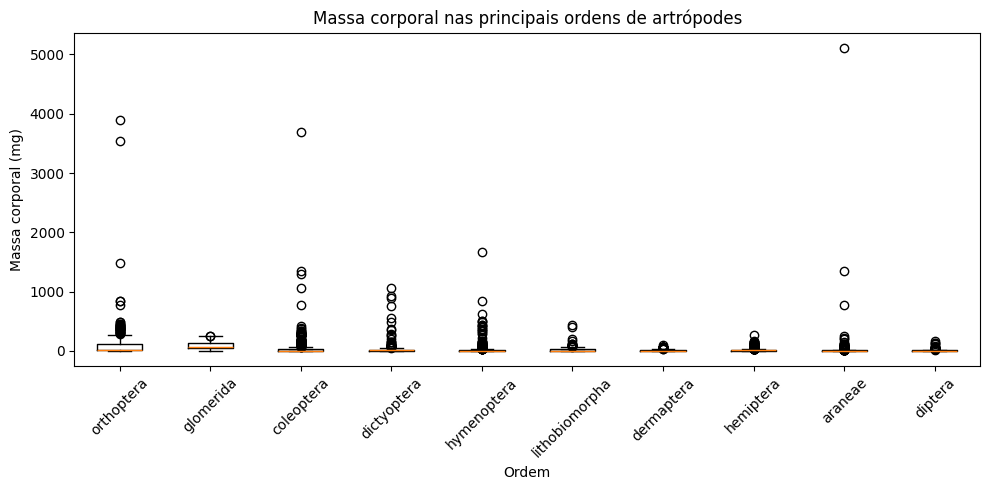

In [21]:
#Boxplot das ordens

ordens = tabela_ordens.index
dados_boxplot = [
    dados_top10[
        dados_top10["Order"] == ordem]["Massa corporal (mg)"].dropna()for ordem in ordens]

plt.figure(figsize=(10,5))

plt.boxplot(dados_boxplot,labels=ordens)

plt.title("Massa corporal nas principais ordens de artrópodes")
plt.xlabel("Ordem")
plt.ylabel("Massa corporal (mg)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Entre as dez ordens mais representadas, Orthoptera apresentou a maior massa corporal média, enquanto Diptera apresentou uma das menores. Entretanto, existe grande dispersão dentro dos grupos.

##Comprimento corporal

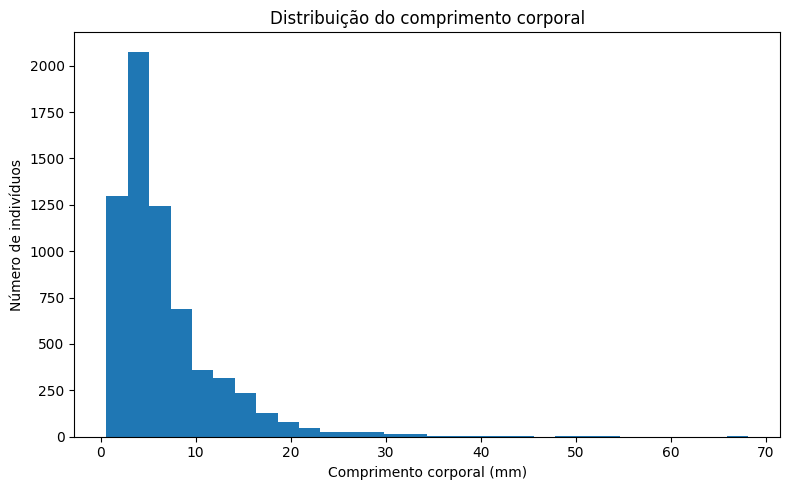

In [22]:
comprimento = df["Comprimento corporal (mm)"].dropna()

plt.figure(figsize=(8,5))

plt.hist(comprimento, bins=30)

plt.title("Distribuição do comprimento corporal")
plt.xlabel("Comprimento corporal (mm)")
plt.ylabel("Número de indivíduos")

plt.tight_layout()
plt.show()

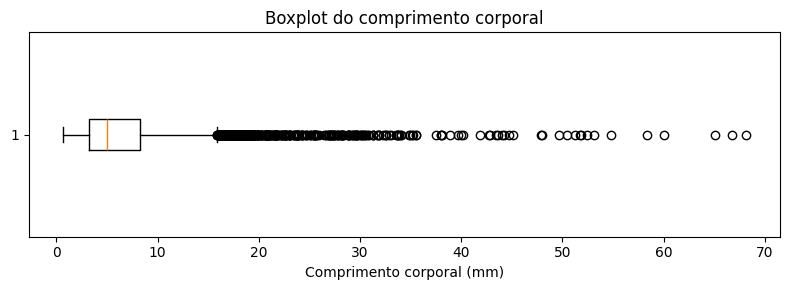

In [23]:
plt.figure(figsize=(8,3))

plt.boxplot(comprimento, vert=False)

plt.title("Boxplot do comprimento corporal")
plt.xlabel("Comprimento corporal (mm)")

plt.tight_layout()
plt.show()

In [24]:
comprimento = df["Comprimento corporal (mm)"].dropna()

Q1 = comprimento.quantile(0.25)
Q3 = comprimento.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

atipicos = comprimento[
    (comprimento < limite_inferior) |
    (comprimento > limite_superior)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)
print("Número de possíveis observações atípicas:", len(atipicos))

Q1: 3.25
Q3: 8.3025
IQR: 5.0525
Limite inferior: -4.32875
Limite superior: 15.881250000000001
Número de possíveis observações atípicas: 438


##Massa x Comprimento

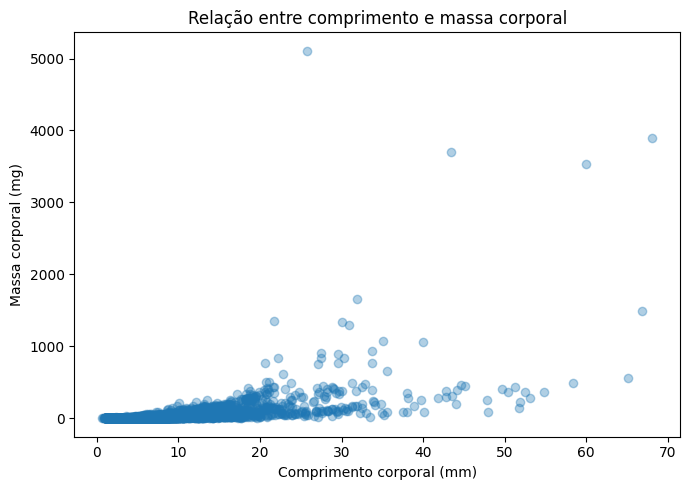

In [25]:
#relação entre massa e comprimento

x = df["Comprimento corporal (mm)"]
y = df["Massa corporal (mg)"]

dados = pd.DataFrame({"Comprimento": x,"Massa": y}).dropna()

plt.figure(figsize=(7,5))

plt.scatter(dados["Comprimento"],dados["Massa"],alpha=0.35)

plt.xlabel("Comprimento corporal (mm)")
plt.ylabel("Massa corporal (mg)")
plt.title("Relação entre comprimento e massa corporal")

plt.tight_layout()
plt.show()

Indivíduos com maior comprimento tendem a apresentar maior massa corporal.

In [26]:
#Correlação de Pearson

correlacoes = df[["Massa corporal (mg)","Comprimento corporal (mm)","Largura corporal (mm)"]].corr()

display(correlacoes.round(3))

,Massa corporal (mg),Comprimento corporal (mm),Largura corporal (mm)
Massa corporal (mg),1.000,0.531,0.596
Comprimento corporal (mm),0.531,1.000,0.719
Largura corporal (mm),0.596,0.719,1.000


Relação
r

Massa × comprimento
0,531

Massa × largura
0,596

Comprimento × largura
0,719

A relação entre comprimento e largura foi a mais forte:
r = 0,719
Isso representa uma associação linear positiva relativamente forte.

Massa × comprimento:
r = 0,531
Associação positiva moderada.

Massa × largura:
r = 0,596
Também uma associação positiva moderada.

##Observações atípicas em relação a massa corporal

IQR (intervalo interquartil), em que uma observação é considerada potencialmente atípica quando:
x < Q1 - 1,5 (IQR)
ou
x < Q3 + 1,5 (IQR)

###Massa
O limite superior calculado foi: 18,04+ 1,5(16,1725) = 42,3 mg

Portanto, qualquer indivíduo com massa acima de aproximadamente 42,3 mg é classificado como potencialmente atípico pelo critério do IQR.
Foram encontrados 869 indivíduos nessa condição.

Isso é extremamente maior que Q3 de 18,04 mg e explica o porque a distribuição da massa é tão assimétrica

###Largura
O limite superior calculado foi: 2,24+ 1,5(1,21) ≈ 4,055

Por isso valores superiores a ≈ 4,06 mm foram classificados como possíveis atípicos, Foram identificadas cerca de 458 observações nessa condição.

###Comprimento
O limite superior calculado foi: 8,30+ 1,5(5,05) ≈ 15,88

Por isso valores superiores a ≈ 15,88 mm foram classificados como possíveis atípicos. Foram identificadas cerca de 438 observações nessa condição

No entanto um valor atípico estatisticamente não é necessariamente um erro de medição ou de digitação.
Estamos trabalhando com artrópodes de diferentes ordens e tamanhos corporais. Portanto, é biologicamente aceitável que alguns grupos apresentem indivíduos muito maiores que outros.
Por exemplo, um artrópode com massa de 100 mg pode ser considerado "atípico" quando comparado à maioria dos indivíduos do banco, mas isso não significa que o dado esteja errado.

###Por que a média e a mediana da massa são tão diferentes?

Porque a distribuição da massa é fortemente assimétrica à direita pois existem alguns indivíduos com massa muito elevada, que aumentam a média, enquanto a mediana permanece mais próxima da massa da maioria dos indivíduos.

###Uma observação atípica é necessariamente um erro?

Não, um valor extremo pode ser um indivíduo biologicamente real, pois o critério do IQR apenas identifica possíveis valores extremos e não determina que eles sejam erros.

###Pode-se afirmar que a região tropical possui artrópodes maiores?

Pode-se afirmar que, nesta amostra, a massa média foi maior na região tropical. Como nossa análise é descritiva, não podemos afirmar significância estatística nem generalizar o resultado para todos os artrópodes tropicais e temperados.

###Por que usar a mediana?

Porque a massa apresenta forte assimetria e a mediana é menos influenciada por valores extremos do que a média.

###Correlação significa que uma variável causa a outra?

Não, a correlação mede associação entre variáveis, mas não demonstra influência.

SOHLSTRÖM, Esra H.; MARIAN, Lucas; BARNES, Andrew D.; et al. Dados de: Aplicação de regressões alométricas generalizadas para prever a massa corporal de artrópodes tropicais e temperados. Dryad, 2018. Publicado em: 07 dez. 2018. Disponível em: https://doi.org/10.5061/dryad.vk24fr1. Acesso em: 18 ago. 2026.

Repositório: Dryad
https://datadryad.org/⁠